In [2]:
import pandas as pd

df = pd.read_csv("data/credit_risk_dataset.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(32581, 12)
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print("Target distribution:")
print(df["loan_status"].value_counts())
print()
print("Target distribution (proportion):")
print(df["loan_status"].value_counts(normalize=True))
print()
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False))

Target distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Target distribution (proportion):
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

Missing values:
loan_int_rate                 3116
person_emp_length              895
person_age                       0
person_income                    0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [4]:
print(df.dtypes)
print("\nCategorical unique values:\n")
for col in ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]:
    print(f"{col}: {df[col].unique()}")

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

Categorical unique values:

person_home_ownership: <StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str
loan_intent: <StringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str
loan_grade: <StringArray>
['D', 'B', 'C', 'A', 'E', 'F', 'G']
Length: 7, dtype: str
cb_person_default_on_file: <StringArray>
['Y', 'N']
Length: 2, dtype: str


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# target and features
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# column groups
categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

# preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (26064, 11)
X_test shape: (6517, 11)
y_train distribution:
 loan_status
0    0.781845
1    0.218155
Name: proportion, dtype: float64
y_test distribution:
 loan_status
0    0.781801
1    0.218199
Name: proportion, dtype: float64


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# baseline pipeline
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

# train
logreg_model.fit(X_train, y_train)

# predict
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8671167715206384
ROC-AUC: 0.8693385451388458

Confusion Matrix:
 [[4852  243]
 [ 623  799]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.77      0.56      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.78      6517
weighted avg       0.86      0.87      0.86      6517



In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.886604265766457
ROC-AUC: 0.8448427831814375

Confusion Matrix:
 [[4682  413]
 [ 326 1096]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93      5095
           1       0.73      0.77      0.75      1422

    accuracy                           0.89      6517
   macro avg       0.83      0.84      0.84      6517
weighted avg       0.89      0.89      0.89      6517



In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9343256099432254
ROC-AUC: 0.930650136851302

Confusion Matrix:
 [[5066   29]
 [ 399 1023]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.9344790547798066
ROC-AUC: 0.9522317183085373

Confusion Matrix:
 [[5059   36]
 [ 391 1031]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.73      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



In [10]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1-Score": f1_score(y_test, y_pred_dt),
        "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-Score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb),
        "Recall": recall_score(y_test, y_pred_xgb),
        "F1-Score": f1_score(y_test, y_pred_xgb),
        "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
    }
])

results = results.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.934479,0.966261,0.725035,0.828445,0.952232
1,Random Forest,0.934326,0.972433,0.719409,0.827001,0.930650
2,Logistic Regression,0.867117,0.766795,0.561885,0.648539,0.869339
3,Decision Tree,0.886604,0.726309,0.770745,0.747868,0.844843


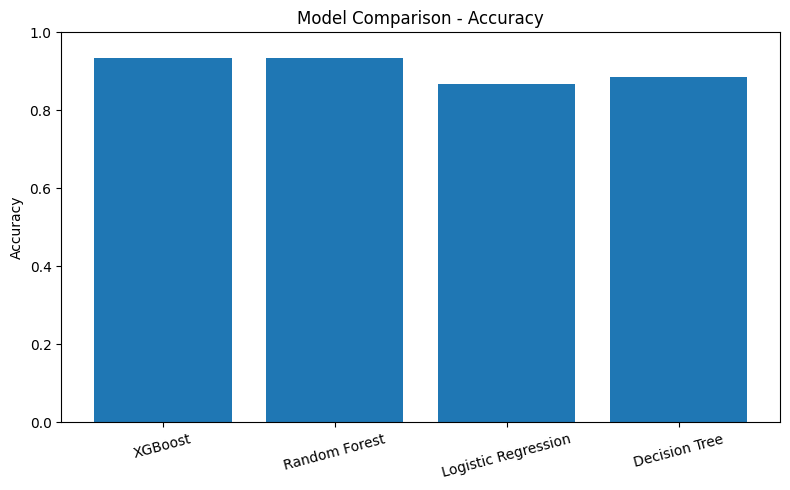

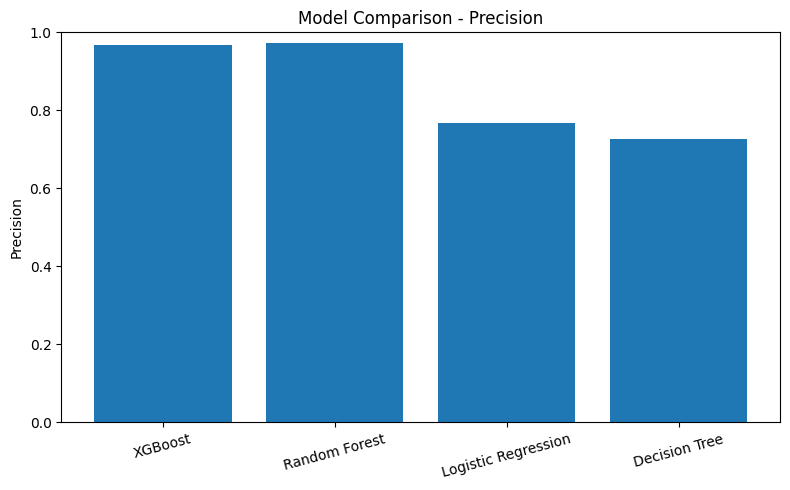

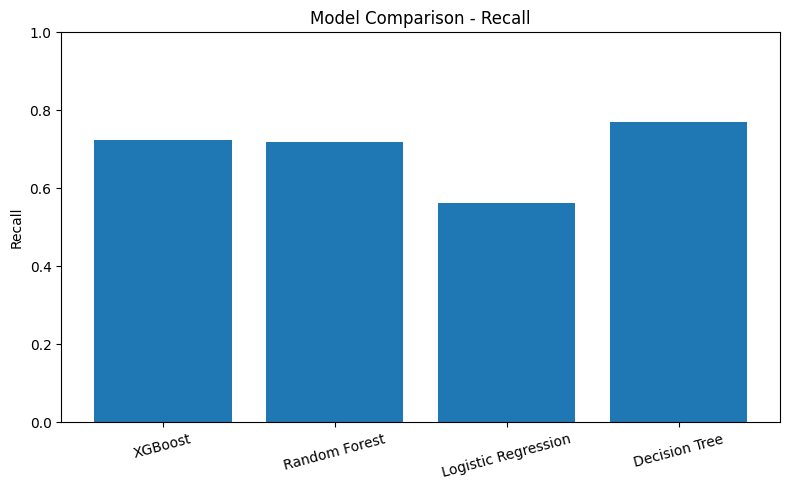

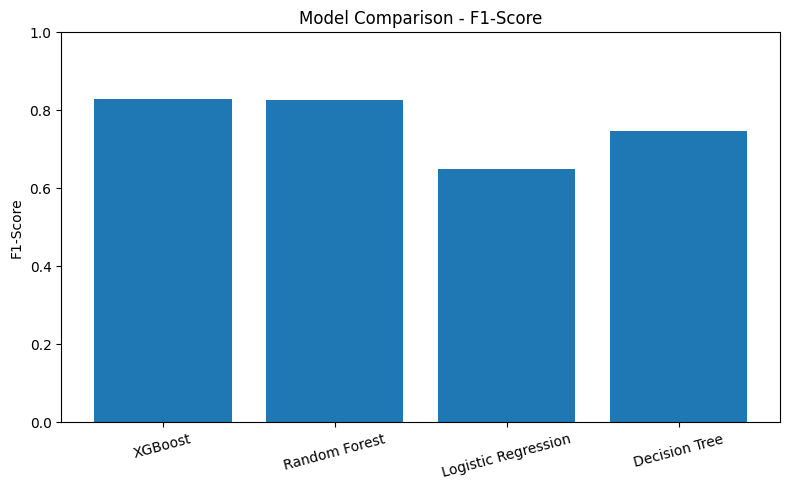

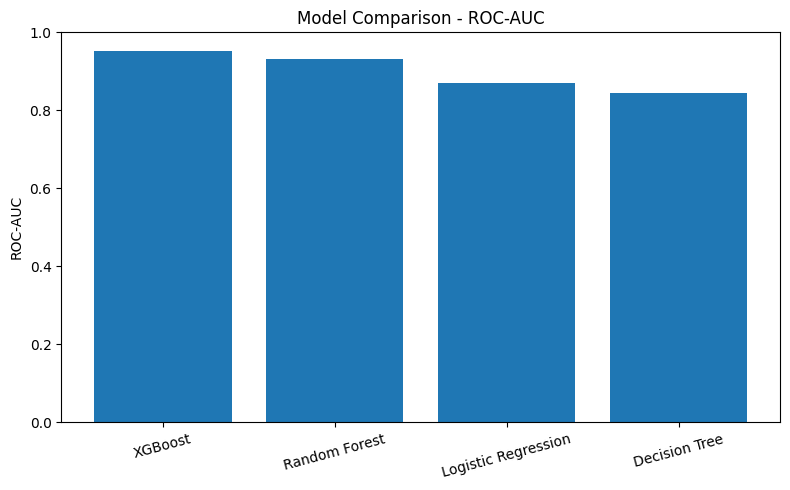

In [11]:
import matplotlib.pyplot as plt

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(results["Model"], results[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [12]:
import shap
import matplotlib.pyplot as plt

# fit preprocessor separately on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# train standalone xgboost on processed data for SHAP
xgb_for_shap = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_for_shap.fit(X_train_processed, y_train)

# shap explainer
explainer = shap.TreeExplainer(xgb_for_shap)
shap_values = explainer.shap_values(X_test_processed)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Number of features after encoding:", len(feature_names))

Processed train shape: (26064, 26)
Processed test shape: (6517, 26)
Number of features after encoding: 26


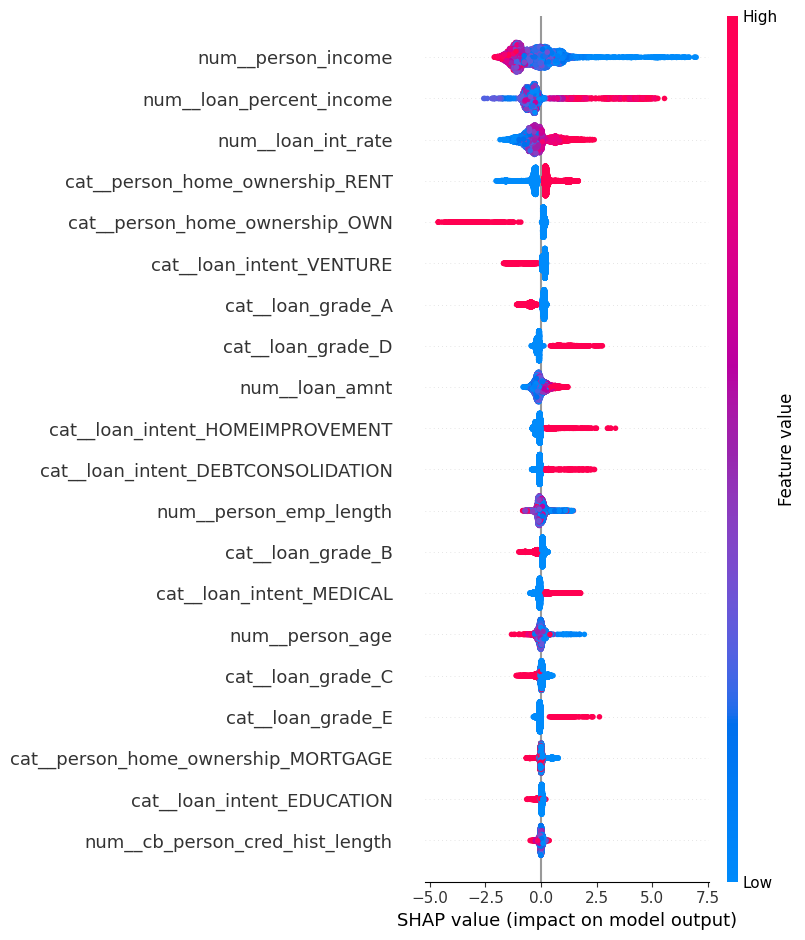

In [13]:
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names)

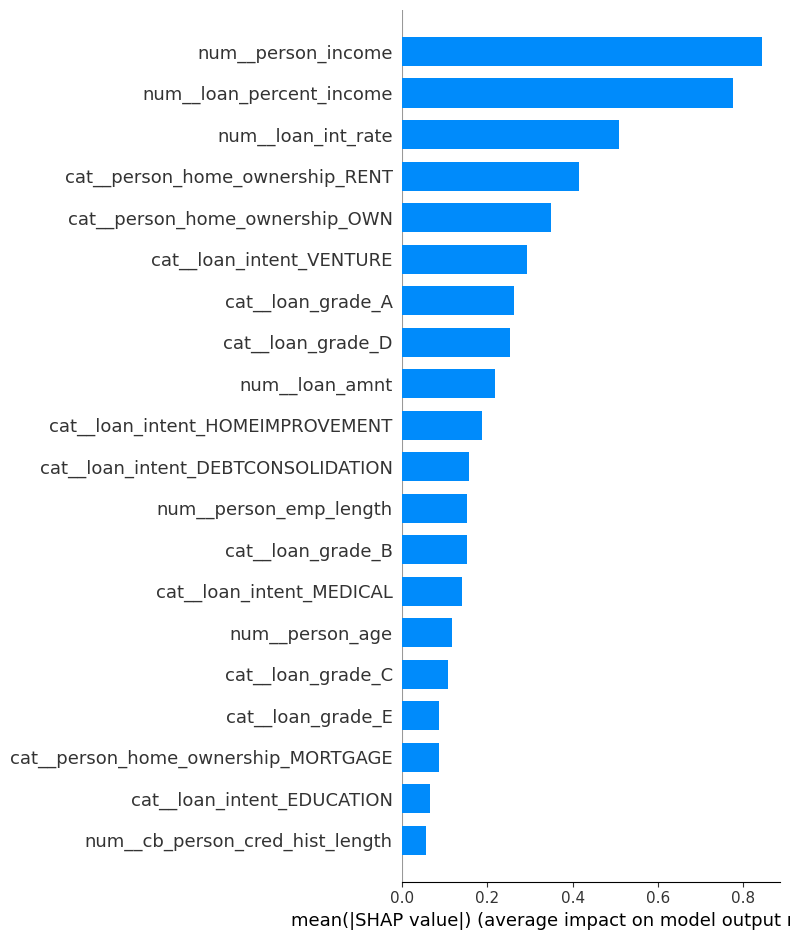

In [15]:
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, plot_type="bar")

Actual class: 0
Predicted probability of default: 0.045450114


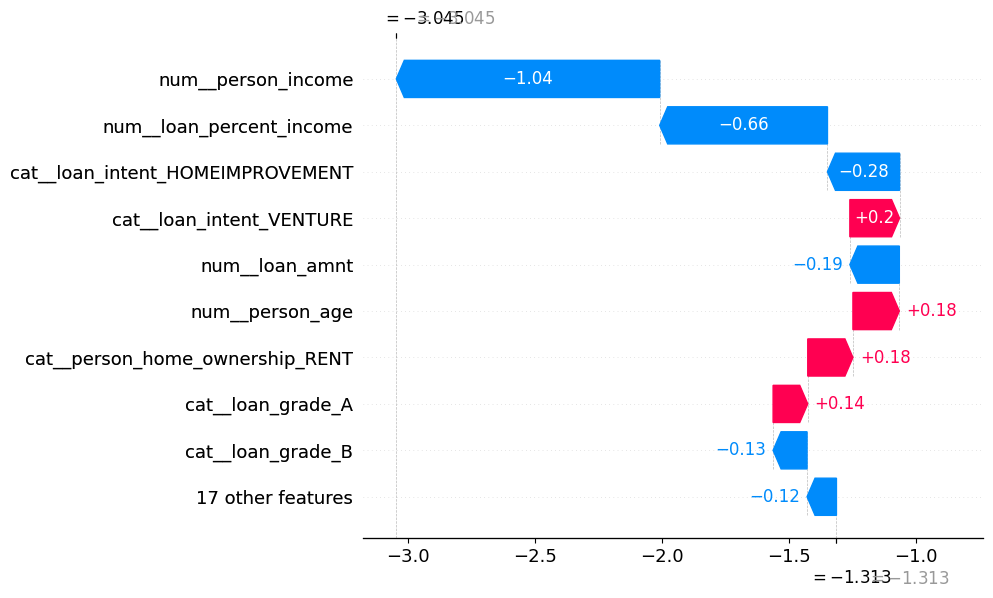

In [16]:
sample_index = 0

print("Actual class:", y_test.iloc[sample_index])
print("Predicted probability of default:", y_prob_xgb[sample_index])

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[sample_index],
    feature_names=feature_names
)